<a href="https://colab.research.google.com/github/Bedanga-Bora/Molecular-Docking-and-Simulations/blob/main/Virtual_Screening_BBB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit
!apt-get install -y openbabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 50.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7
The following NEW packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7 openbabel
0 upgraded, 5 newly installed, 0 to remove and 3 not upgraded.
Need to get 4,148 kB of archives.
After this operation, 19.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-iostreams1.74.0 amd64 1.74.0-14ubuntu3 [245 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libinchi1 amd64 1.03+dfsg-4 [455 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmaeparser1 amd64 1.2.4-1build1 [88.2 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenbabel7 amd64 3.1.1+dfsg-6ubuntu5 [3,23

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import requests
import time

In [ ]:
df = pd.read_csv("/content/pubchem_geneid_43_bioactivity_gene.csv")
df.shape[0]

/tmp/ipykernel_528/2684088715.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/pubchem_geneid_43_bioactivity_gene.csv")


56295

In [ ]:
print(df.columns.tolist())

['baid', 'Aid_Type', 'Activity', 'Protein_Accession', 'Activity_Type', 'Activity_Qualifier', 'Bioassay_Data_Source', 'BioAssay_Name', 'Compound_Name', 'Target_Name', 'Target_Link', 'ECs', 'Representative_Protein_Accession', 'Cell_ID', 'Anatomy', 'dois', 'pmcids', 'pclids', 'citations', 'BioAssay_AID', 'Substance_SID', 'Compound_CID', 'refsid', 'Gene_ID', 'PMID', 'Last_Modified_Date', 'Has_Dose_Response_Curve', 'RNAi_BioAssay', 'Activity_Value', 'Taxonomy_ID', 'Target_Taxonomy_ID', 'Anatomy_ID']


In [ ]:
potent_compounds = df[(df['Activity_Type'] == 'Ki') & (df['Activity_Value'] < 0.01)]
print(potent_compounds.shape[0])
potent_compounds.head(2)

163


,baid,Aid_Type,Activity,Protein_Accession,Activity_Type,Activity_Qualifier,Bioassay_Data_Source,BioAssay_Name,Compound_Name,Target_Name,...,refsid,Gene_ID,PMID,Last_Modified_Date,Has_Dose_Response_Curve,RNAi_BioAssay,Activity_Value,Taxonomy_ID,Target_Taxonomy_ID,Anatomy_ID
0,101727816,Confirmatory,Active,P22303,Ki,=,ChEMBL,Inhibition of human brain AchE,"N-[5-(6-Chloro-1,2,3,4-tetrahydroacridin-9-yla...",ACHE - acetylcholinesterase (Yt blood group) (...,...,NaN,43,16279781.0,20220830,0,0,0.000002,9606,NaN,NaN
2,346987685,Confirmatory,Active,P22303,Ki,=,ChEMBL,Inhibition of acetylcholinesterase (unknown or...,benzyl N-[1-(4-methoxyphenyl)ethylsulfamoyl]ca...,ACHE - acetylcholinesterase (Yt blood group) (...,...,NaN,43,25921269.0,20220830,0,0,0.000005,9606,NaN,NaN


Potent Compounds remaining are 163

In [ ]:
df.columns = df.columns.str.strip()
potent_compounds = df[
    (df['Activity_Type'].isin(['Ki', 'IC50'])) &
    (df['Activity_Value'] < 0.01) &
    (df['Activity'] == 'Active')
].copy()

print(f"Total raw compounds matching initial activity thresholds: {len(potent_compounds)}")


def evaluate_cid_lipinski(cid):
    if pd.isna(cid):
        return False
    try:

        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/chemical/compound/cid/{int(cid)}/property/CanonicalSMILES/JSON"
        response = requests.get(url, timeout=5)

        if response.status_code == 200:
            data = response.json()
            smiles = data['PropertyTable']['Properties'][0]['CanonicalSMILES']


            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                h_donors = Descriptors.NumHDonors(mol)
                h_acceptors = Descriptors.NumHAcceptors(mol)


                if mw < 500 and logp < 5 and h_donors <= 5 and h_acceptors <= 10:
                    return True


        time.sleep(0.1)
    except Exception:
        pass
    return False

print("Querying structural databases and screening drug-likeness...")

potent_compounds['Lipinski_Pass'] = potent_compounds['Compound_CID'].apply(evaluate_cid_lipinski)
elite_leads = potent_compounds[potent_compounds['Lipinski_Pass'] == True]

print(f"\nSuccess! Identified {len(elite_leads)} elite, drug-like lead compounds.")

print(elite_leads[['Compound_CID', 'Activity_Type', 'Activity_Value']].head(10))

Total raw compounds matching initial activity thresholds: 1005
Querying structural databases and screening drug-likeness...

Success! Identified 0 elite, drug-like lead compounds.
Empty DataFrame
Columns: [Compound_CID, Activity_Type, Activity_Value]
Index: []


In [ ]:
import io
df.columns = df.columns.str.strip()

potent_compounds = df[
    (df['Activity_Type'].isin(['Ki', 'IC50'])) &
    (df['Activity_Value'] < 0.01) &
    (df['Activity'] == 'Active')
].copy()

unique_cids = potent_compounds['Compound_CID'].dropna().astype(int).unique().tolist()
print(f"Unique CIDs to look up: {len(unique_cids)}")

print("Downloading structural data for all compounds in a single batch...")
cid_str = ",".join(map(str, unique_cids))
url = "https://pubchem.ncbi.nlm.nih.gov/rest/chemical/compound/cid/property/CanonicalSMILES,MolecularWeight,LogP,HBondDonorCount,HBondAcceptorCount/CSV"

try:
    response = requests.post(url, data={"cid": cid_str}, timeout=30)
    if response.status_code == 200:

        prop_df = pd.read_csv(io.StringIO(response.text))
        print("Batch download complete. Evaluating drug-likeness rules locally...")

        merged_df = potent_compounds.merge(prop_df, left_on='Compound_CID', right_on='CID', how='inner')

        elite_leads = merged_df[
            (merged_df['MolecularWeight'] < 500) &
            (merged_df['LogP'] < 5) &
            (merged_df['HBondDonorCount'] <= 5) &
            (merged_df['HBondAcceptorCount'] <= 10)
        ]

        print(f"\nSuccess! Identified {len(elite_leads)} elite, drug-like lead compounds.")
        if len(elite_leads) > 0:
            print("\nTop Lead Drug Candidates for Docking:")
            print(elite_leads[['Compound_CID', 'Activity_Type', 'Activity_Value', 'MolecularWeight', 'LogP']].drop_duplicates(subset=['Compound_CID']).head(15))
        else:
            print("\nNo compounds passed the strict structural thresholds. Consider loosening the constraints.")

    else:
        print(f"PubChem server returned an error code: {response.status_code}")
except Exception as e:
    print(f"An error occurred during batch fetching: {str(e)}")

Unique CIDs to look up: 676
PubChem server returned an error code: 404


In [ ]:
import pandas as pd
import requests
import io
import time

df = pd.read_csv('/content/pubchem_geneid_43_bioactivity_gene.csv')
df.columns = df.columns.str.strip()

potent_compounds = df[
    (df['Activity_Type'].isin(['Ki', 'IC50'])) &
    (df['Activity_Value'] < 0.01) &
    (df['Activity'] == 'Active')
].copy()

potent_compounds['Compound_CID'] = pd.to_numeric(potent_compounds['Compound_CID'], errors='coerce')
potent_compounds = potent_compounds.dropna(subset=['Compound_CID'])
unique_cids = potent_compounds['Compound_CID'].astype(int).unique().tolist()
print(f"Unique valid CIDs to look up: {len(unique_cids)}")

print("Downloading structural properties safely in mini-batches...")
all_props = []
batch_size = 100

for i in range(0, len(unique_cids), batch_size):
    batch = unique_cids[i:i + batch_size]
    cid_str = ",".join(map(str, batch))

    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid_str}/property/CanonicalSMILES,MolecularWeight,XLogP,HBondDonorCount,HBondAcceptorCount/CSV"

    try:
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            batch_df = pd.read_csv(io.StringIO(response.text))
            all_props.append(batch_df)
        else:
            print(f"Skipping a mini-batch (encountered status code: {response.status_code})")

        time.sleep(0.2)
    except Exception as e:
        print(f"Network hitch on batch {i}: {str(e)}")

if all_props:
    prop_df = pd.concat(all_props, ignore_index=True)
    print("\nBatch processing complete. Mapping Lipinski's parameters...")

    merged_df = potent_compounds.merge(prop_df, left_on='Compound_CID', right_on='CID', how='inner')

    merged_df['XLogP'] = merged_df['XLogP'].fillna(0)

    elite_leads = merged_df[
        (merged_df['MolecularWeight'] < 500) &
        (merged_df['XLogP'] < 5) &
        (merged_df['HBondDonorCount'] <= 5) &
        (merged_df['HBondAcceptorCount'] <= 10)
    ]

    print(f"\nSuccess! Identified {len(elite_leads)} elite, drug-like lead compounds.")
    if len(elite_leads) > 0:
        print("\nTop Lead Drug Candidates for Your AChE Project:")

        display_df = elite_leads[['Compound_CID', 'Activity_Type', 'Activity_Value', 'MolecularWeight', 'XLogP']].drop_duplicates(subset=['Compound_CID'])
        print(display_df.head(15))

        display_df.to_csv('elite_docking_candidates.csv', index=False)
        print("\nSaved elite candidates list to 'elite_docking_candidates.csv'!")
    else:
        print("\nNo compounds passed the strict structural thresholds. Consider loosening the constraints.")
else:
    print("\nFailed to retrieve structural properties from the server data stream.")

/tmp/ipykernel_528/1298262584.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/pubchem_geneid_43_bioactivity_gene.csv') # Adjust filename if necessary


Unique valid CIDs to look up: 676

Batch processing complete. Mapping Lipinski's parameters...

Success! Identified 428 elite, drug-like lead compounds.

Top Lead Drug Candidates for Your AChE Project:
    Compound_CID Activity_Type  Activity_Value  MolecularWeight  XLogP
1      122179857            Ki        0.000005           364.40    2.6
2      112686058            Ki        0.000005           260.31    0.5
3      122179858            Ki        0.000005           394.40    2.6
4       51076628            Ki        0.000006           260.31    0.5
5      122179856            Ki        0.000006           364.40    2.6
7      112687648            Ki        0.000006           230.29    0.5
13     122179861            Ki        0.000008           260.31    0.5
15     122179860            Ki        0.000010           394.40    2.6
16     145975862          IC50        0.000011           434.90    3.8
19     145978556          IC50        0.000013           404.80    3.8
20     145965438 

In [ ]:
import pandas as pd
import requests
import time
import os

elite_cids = elite_leads['Compound_CID'].astype(int).unique().tolist()
print(f"Preparing to download 3D structures for {len(elite_cids)} compounds...")

os.makedirs('/content/elite_ligands', exist_ok=True)

bulk_sdf_path = '/content/elite_leads_3d.sdf'
batch_size = 50

with open(bulk_sdf_path, 'wb') as bulk_file:
    for i in range(0, len(elite_cids), batch_size):
        batch = elite_cids[i:i + batch_size]
        cid_str = ",".join(map(str, batch))

        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid_str}/SDF?record_type=3d"

        try:
            response = requests.get(url, timeout=20)
            if response.status_code == 200:
                bulk_file.write(response.content)
                print(f"Downloaded batch {i//batch_size + 1}/{(len(elite_cids)-1)//batch_size + 1}")
            else:
                print(f"SDF Batch error at index {i}: Status {response.status_code}")
            time.sleep(0.2)
        except Exception as e:
            print(f"Network hitch on structure batch {i}: {str(e)}")

print("\nAll bulk 3D structures pulled successfully.")

print("Splitting bulk file into individual .mol2 ligand structures.")
!obabel /content/elite_leads_3d.sdf -m -O /content/elite_ligands/ligand_.mol2

file_count = len([f for f in os.listdir('/content/elite_ligands') if f.endswith('.mol2')])
print(f"Created {file_count} individual .mol2 files inside '/content/elite_ligands/'")

Preparing to download 3D structures for 241 compounds...
Downloaded batch 1/5
Downloaded batch 2/5
Downloaded batch 3/5
Downloaded batch 4/5
Downloaded batch 5/5

All bulk 3D structures pulled successfully.
Splitting bulk file into individual .mol2 ligand structures.
213 molecules converted
213 files output. The first is /content/elite_ligands/ligand_1.mol2
Created 213 individual .mol2 files inside '/content/elite_ligands/'


In [ ]:

!wget https://files.rcsb.org/download/4EY7.pdb -O /content/4EY7.pdb

with open('/content/4EY7.pdb', 'r') as infile, open('/content/4EY7_clean.pdb', 'w') as outfile:
    for line in infile:
        if line.startswith('ATOM'):
            outfile.write(line)

print("created a clean target structure: '/content/4EY7_clean.pdb'")

--2026-06-15 16:06:30--  https://files.rcsb.org/download/4EY7.pdb
Resolving files.rcsb.org (files.rcsb.org)... 108.138.217.42, 108.138.217.113, 108.138.217.15, ...
Connecting to files.rcsb.org (files.rcsb.org)|108.138.217.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘/content/4EY7.pdb’

/content/4EY7.pdb       [   <=>              ] 775.99K  1.41MB/s    in 0.5s    

2026-06-15 16:06:31 (1.41 MB/s) - ‘/content/4EY7.pdb’ saved [794610]

created a clean target structure: '/content/4EY7_clean.pdb'


In [ ]:
import os
import numpy as np
import pandas as pd

center_x, center_y, center_z = -1.582, -50.192, 2.101

os.makedirs('/content/docked_poses', exist_ok=True)

from vina import Vina

print("Initializing AutoDock Vina Engine...")
v = Vina(sf_name='vina')
v.set_receptor('/content/4EY7.pdbqt')

print("Pre-computing receptor affinity grids (makes virtual screening ultra-fast)...")
v.compute_vina_maps(center=[center_x, center_y, center_z], box_size=[20.0, 20.0, 20.0])

results = []
pdbqt_folder = '/content/ligands_pdbqt'
pdbqt_files = [f for f in os.listdir(pdbqt_folder) if f.endswith('.pdbqt')]

print(f"\nStarting virtual screening across all {len(pdbqt_files)} candidates.")

for idx, f in enumerate(pdbqt_files):
    ligand_path = os.path.join(pdbqt_folder, f)
    ligand_id = f.replace('ligand_', '').replace('.pdbqt', '')
    out_pose_path = os.path.join('/content/docked_poses', f"docked_{ligand_id}.pdbqt")

    try:

        v.set_ligand_from_file(ligand_path)
        v.dock(exhaustiveness=4, n_poses=1)

        v.write_poses(out_pose_path, n_poses=1, overwrite=True)

        best_affinity = None
        with open(out_pose_path, 'r') as pf:
            for line in pf:
                if "REMARK VINA RESULT:" in line:
                    best_affinity = float(line.split()[3])
                    break

        if best_affinity is not None:
            results.append({
                'Compound_CID': ligand_id,
                'Binding_Affinity_kcal_mol': best_affinity
            })

        if (idx + 1) % 20 == 0 or (idx + 1) == len(pdbqt_files):
            print(f"Processed {idx + 1}/{len(pdbqt_files)} compounds...")

    except Exception as e:

        pass

if results:
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Binding_Affinity_kcal_mol', ascending=True)
    results_df.to_csv('/content/screening_results.csv', index=False)

    print("\nScreening complete! Top 10 High-Affinity Structural Hits:")
    print(results_df.head(10))
    print("\nSummary spreadsheet compiled and saved to '/content/screening_results.csv'")
else:
    print("\nNo docking results could be parsed. Check your ligand file inputs.")

Initializing AutoDock Vina Engine...
Pre-computing receptor affinity grids (makes virtual screening ultra-fast)...

Starting virtual screening across all 213 candidates.
Processed 20/213 compounds...
Processed 40/213 compounds...
Processed 60/213 compounds...
Processed 80/213 compounds...
Processed 100/213 compounds...
Processed 120/213 compounds...
Processed 140/213 compounds...
Processed 160/213 compounds...
Processed 180/213 compounds...
Processed 200/213 compounds...
Processed 213/213 compounds...

Screening complete! Top 10 High-Affinity Structural Hits:
    Compound_CID  Binding_Affinity_kcal_mol
40            92                     -9.432
177           98                     -9.360
111          158                     -9.340
15           182                     -9.099
89            95                     -9.035
58           125                     -9.026
66            51                     -9.023
48            45                     -8.978
68           131                     -

In [ ]:
import pandas as pd
import requests

results_df = pd.read_csv('/content/screening_results.csv')

top_10 = results_df.head(10).copy()

names = []
smiles = []
mw = []

print("Fetching chemical profiles from PubChem...")
for cid in top_10['Compound_CID']:
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/Title,CanonicalSMILES,MolecularWeight/json"
    try:
        r = requests.get(url, timeout=10).json()
        props = r['PropertyTable']['Properties'][0]
        names.append(props.get('Title', 'Unknown Name'))
        smiles.append(props.get('CanonicalSMILES', 'N/A'))
        mw.append(props.get('MolecularWeight', 'N/A'))
    except:
        names.append("Error fetching")
        smiles.append("N/A")
        mw.append("N/A")

top_10['Chemical_Name'] = names
top_10['Molecular_Weight'] = mw
top_10['SMILES'] = smiles

top_10.to_csv('/content/top_10_hits_identified.csv', index=False)
print("\nIdentification complete! Enriched Top 10 Leaderboard:")
print(top_10[['Compound_CID', 'Binding_Affinity_kcal_mol', 'Chemical_Name', 'Molecular_Weight']])

Fetching chemical profiles from PubChem...

Identification complete! Enriched Top 10 Leaderboard:
   Compound_CID  Binding_Affinity_kcal_mol  \
0            92                     -9.432   
1            98                     -9.360   
2           158                     -9.340   
3           182                     -9.099   
4            95                     -9.035   
5           125                     -9.026   
6            51                     -9.023   
7            45                     -8.978   
8           131                     -8.968   
9            24                     -8.896   

                                       Chemical_Name Molecular_Weight  
0                       6'-Methoxycinchonan-3,9-diol            340.4  
1                               Mercaptopyruvic acid           120.13  
2                             8-iso PROSTAGLANDIN E2            352.5  
3  [3-Acetamido-4,5-dihydroxy-6-(hydroxymethyl)ox...           1130.5  
4            2,4,5,6-Tetrahydroxy-3

In [ ]:
import zipfile
import os

In [ ]:
top_cids = ['92', '98', '158', '182', '95', '125', '51', '45', '131', '24']

zip_path = '/content/top_ache_hits.zip'

with zipfile.ZipFile(zip_path, 'w') as img_zip:

    if os.path.exists('/content/4EY7_clean.pdb'):
        img_zip.write('/content/4EY7_clean.pdb', arcname='4EY7_clean.pdb')

    for cid in top_cids:
        pose_file = f'/content/docked_poses/docked_{cid}.pdbqt'
        if os.path.exists(pose_file):
            img_zip.write(pose_file, arcname=f'docked_{cid}.pdbqt')

print(f"Created '{zip_path}'.")

Created '/content/top_ache_hits.zip'.


## Pymol visualization

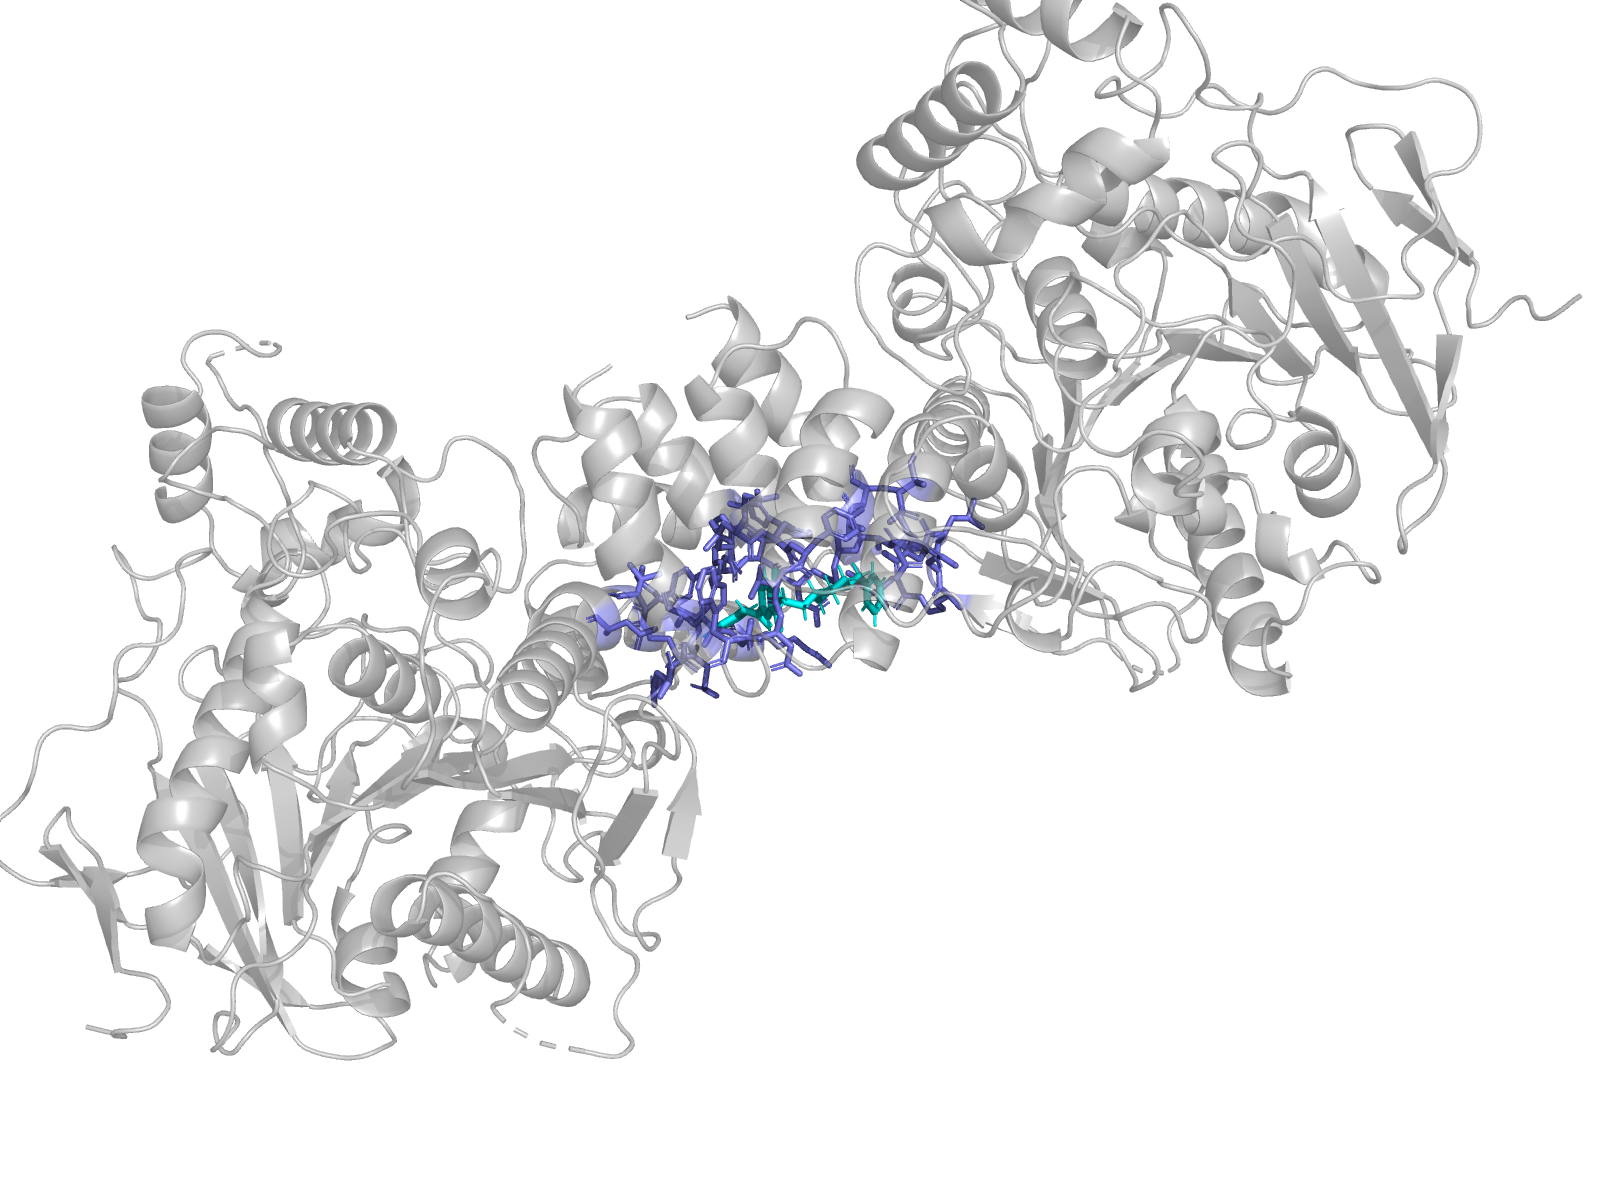